# YOLO OBB — Model Evaluation & Visualisation

Everything in one place:
1. **Training curves** — did the model converge?
2. **Confidence sweep** — how does threshold affect precision/recall?
3. **Single-image deep dive** — raw detections, score heatmap, warped crop
4. **Real-photo batch** — your actual card photos
5. **Synthetic val set** — ground-truth vs predicted IoU
6. **Failure analysis** — misses, false positives, low-confidence hits
7. **Base model comparison** — custom vs untrained YOLO11n-obb


In [1]:
# ── Imports & paths ────────────────────────────────────────────────────────────
from pathlib import Path
import glob, random, textwrap
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pandas as pd
from ultralytics import YOLO

# ── CONFIG ─────────────────────────────────────────────────────────────────────
DATASET_OUT  = Path("datasets/yolo_obb_cards")
BASE_MODEL   = "yolo11n-obb.pt"          # untrained reference
CONF_DEFAULT = 0.25
SEED         = 42

# ── MODEL SELECTOR ─────────────────────────────────────────────────────────────
# Choose which run to evaluate:
#   "auto"     → newest best.pt found anywhere (T2 or T5, whichever is newer)
#   "train"    → T2 run  (datasets/yolo_obb_cards/train/weights/best.pt)
#   "finetune" → T5 run  (datasets/yolo_obb_cards/finetune/weights/best.pt)
#   "path"     → explicit path set in CUSTOM_PATH below
MODEL_SOURCE = "train"# "auto"
CUSTOM_PATH  = ""    # only used when MODEL_SOURCE = "path"
# ─────────────────────────────────────────────────────────────────────────────

def _find_best(run_name: str):
    """Search for best.pt for a given run name in all likely locations."""
    candidates = sorted(
        glob.glob(str(Path.home() / "**" / "yolo_obb_cards" / f"{run_name}*" / "weights" / "best.pt"), recursive=True) +
        glob.glob(str(Path("/opt/homebrew/runs") / "**" / "yolo_obb_cards" / f"{run_name}*" / "weights" / "best.pt"), recursive=True) +
        glob.glob(str(DATASET_OUT / f"{run_name}*" / "weights" / "best.pt")),
        key=lambda p: Path(p).stat().st_mtime, reverse=True,
    )
    return Path(candidates[0]) if candidates else None

def _resolve_weights():
    if MODEL_SOURCE == "path":
        p = Path(CUSTOM_PATH)
        return p if p.exists() else None
    if MODEL_SOURCE == "train":
        return _find_best("train")
    if MODEL_SOURCE == "finetune":
        return _find_best("finetune")
    # "auto" — newest across both
    candidates = sorted(
        glob.glob(str(Path.home() / "**" / "yolo_obb_cards" / "train*" / "weights" / "best.pt"), recursive=True) +
        glob.glob(str(Path("/opt/homebrew/runs") / "**" / "yolo_obb_cards" / "train*" / "weights" / "best.pt"), recursive=True) +
        glob.glob(str(Path("/opt/homebrew/runs") / "**" / "yolo_obb_cards" / "finetune*" / "weights" / "best.pt"), recursive=True) +
        glob.glob(str(DATASET_OUT / "train*" / "weights" / "best.pt")) +
        glob.glob(str(DATASET_OUT / "finetune*" / "weights" / "best.pt")),
        key=lambda p: Path(p).stat().st_mtime, reverse=True,
    )
    return Path(candidates[0]) if candidates else None

BEST_WEIGHTS = _resolve_weights()

# Derive TRAIN_DIR from the weights path (for training curves in §1)
TRAIN_DIR = BEST_WEIGHTS.parent.parent if (BEST_WEIGHTS and BEST_WEIGHTS.exists()) else None

# Real card photos
REAL_PHOTOS = sorted(
    glob.glob("ungraded/*_front*.jpeg") + glob.glob("ungraded/abhi_*.jpg")
)
REAL_PHOTOS = [p for p in REAL_PHOTOS if "extracted" not in p and "output" not in p]

# ── Summary ────────────────────────────────────────────────────────────────────
# Discover all available runs to show the user their options
_all_runs = {}
for _rname in ["train", "finetune"]:
    _p = _find_best(_rname)
    if _p:
        import os, datetime
        _mtime = datetime.datetime.fromtimestamp(os.path.getmtime(_p)).strftime("%Y-%m-%d %H:%M")
        _all_runs[_rname] = (_p, _mtime)

print("Available runs:")
for _rname, (_p, _t) in _all_runs.items():
    marker = " ◀ selected" if (BEST_WEIGHTS and str(_p) == str(BEST_WEIGHTS)) else ""
    print(f"  [{_rname:10s}]  {_p}  (saved {_t}){marker}")
if not _all_runs:
    print("  ⚠️  No trained weights found — run T2 in train_yolo_obb.ipynb first")

print(f"\nMODEL_SOURCE : {MODEL_SOURCE!r}")
print(f"BEST_WEIGHTS : {BEST_WEIGHTS}")
print(f"  exists     : {BEST_WEIGHTS.exists() if BEST_WEIGHTS else False}")
print(f"TRAIN_DIR    : {TRAIN_DIR}")
print(f"Real photos  : {len(REAL_PHOTOS)} files")


Available runs:
  [train     ]  /opt/homebrew/runs/obb/datasets/yolo_obb_cards/train2/weights/best.pt  (saved 2026-05-26 10:23) ◀ selected
  [finetune  ]  /opt/homebrew/runs/obb/datasets/yolo_obb_cards/finetune-2/weights/best.pt  (saved 2026-05-26 10:39)

MODEL_SOURCE : 'train'
BEST_WEIGHTS : /opt/homebrew/runs/obb/datasets/yolo_obb_cards/train2/weights/best.pt
  exists     : True
TRAIN_DIR    : /opt/homebrew/runs/obb/datasets/yolo_obb_cards/train2
Real photos  : 14 files


## 1 — Training Curves
Did the model converge? Loss going down, mAP going up?

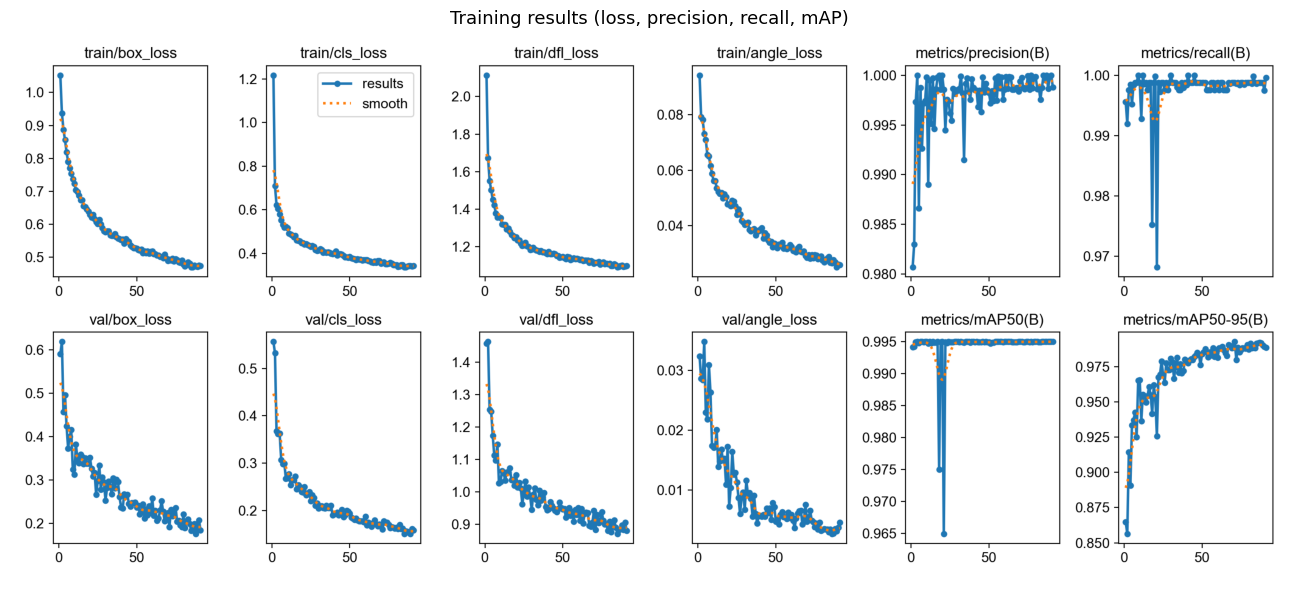

In [2]:
# ── 1A: results.png (ultralytics summary plot) ─────────────────────────────────
results_png = TRAIN_DIR / "results.png"
if results_png.exists():
    img = plt.imread(str(results_png))
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Training results (loss, precision, recall, mAP)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print(f"results.png not found at {results_png}")

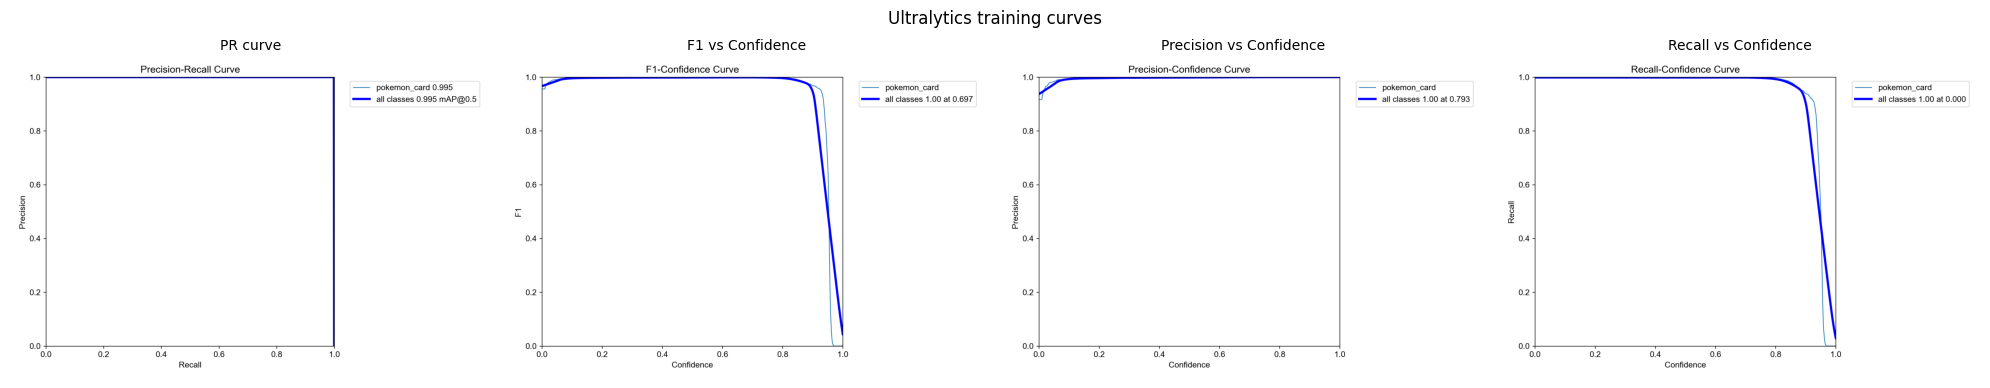

In [3]:
# ── 1B: PR, F1, P, R curves ────────────────────────────────────────────────────
curve_names = ["BoxPR_curve", "BoxF1_curve", "BoxP_curve", "BoxR_curve"]
titles      = ["PR curve", "F1 vs Confidence", "Precision vs Confidence", "Recall vs Confidence"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name, title in zip(axes, curve_names, titles):
    p = TRAIN_DIR / f"{name}.png"
    if p.exists():
        ax.imshow(plt.imread(str(p)))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, "not found", ha="center", va="center")
    ax.axis("off")
plt.suptitle("Ultralytics training curves", fontsize=12)
plt.tight_layout()
plt.show()

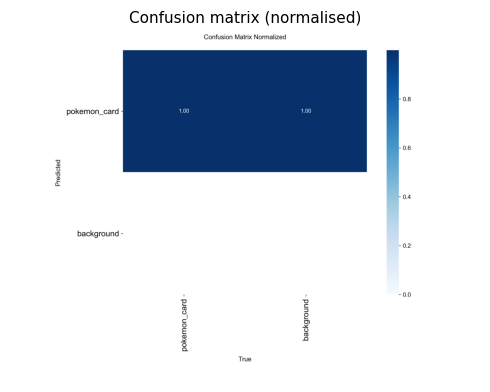

In [4]:
# ── 1C: Confusion matrix ───────────────────────────────────────────────────────
cm_png = TRAIN_DIR / "confusion_matrix_normalized.png"
if cm_png.exists():
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(plt.imread(str(cm_png)))
    ax.axis("off")
    ax.set_title("Confusion matrix (normalised)", fontsize=11)
    plt.tight_layout()
    plt.show()

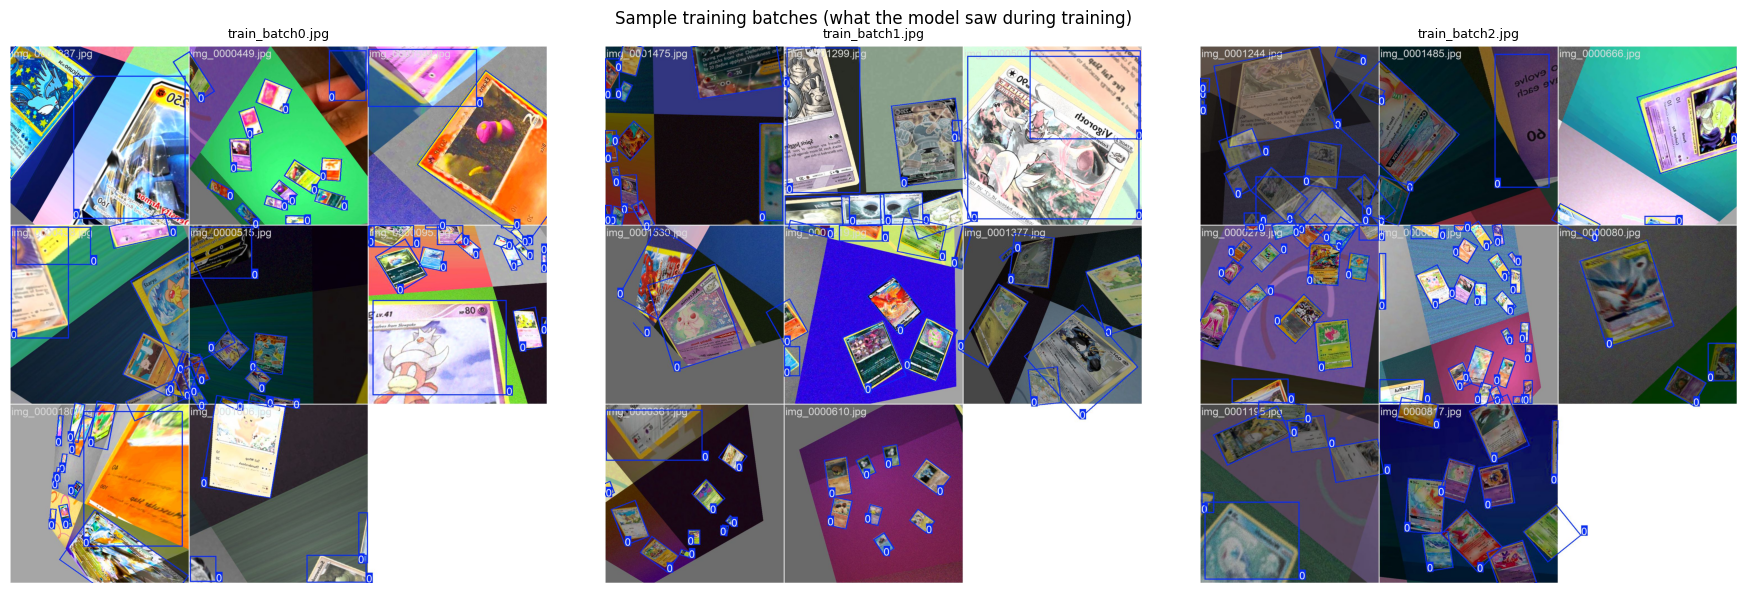

In [5]:
# ── 1D: Sample training batches seen by the model ─────────────────────────────
batch_imgs = sorted(TRAIN_DIR.glob("train_batch*.jpg"))
fig, axes = plt.subplots(1, min(3, len(batch_imgs)), figsize=(18, 6))
if len(batch_imgs) == 1: axes = [axes]
for ax, p in zip(axes, batch_imgs[:3]):
    ax.imshow(plt.imread(str(p)))
    ax.set_title(p.name, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training batches (what the model saw during training)", fontsize=12)
plt.tight_layout()
plt.show()

## 2 — Load Model & Confidence Sweep
Run the model at several confidence thresholds to understand the precision/recall trade-off on your real photos.

In [6]:
assert BEST_WEIGHTS and BEST_WEIGHTS.exists(), "Run B6 training first — no best.pt found"
model = YOLO(str(BEST_WEIGHTS))
print(f"Loaded: {BEST_WEIGHTS.name}")
print(f"Task  : {model.task}")
print(f"Names : {model.names}")

Loaded: best.pt
Task  : obb
Names : {0: 'pokemon_card'}


In [7]:
def plot_detection(image, conf: float, d: int, model=model,
                   out_w: int = 300, card_ratio: float = 63/88,
                   figsize=(14, 6)):
    """
    Run the model on `image` at threshold `conf` and visualise detection index `d`.

    Parameters
    ----------
    image    : str | Path | np.ndarray   — file path or BGR array
    conf     : float                     — confidence threshold (0–1)
    d        : int                       — which detection to highlight (0-indexed)
    model    : YOLO                      — loaded YOLO model (defaults to `model`)
    out_w    : int                       — width of the warped crop output
    card_ratio: float                    — card aspect ratio w/h (63/88 for Pokémon)
    figsize  : tuple                     — overall figure size

    Layout
    ------
    [full image + all boxes (grey) + box d (bright)]  |  [warped crop of d]  |  [corner table]
    """
    import numpy as np
    import cv2
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.gridspec import GridSpec

    # ── load image ───────────────────────────────────────────────────────────
    if isinstance(image, (str, Path)):
        img_bgr = cv2.imread(str(image))
        img_label = Path(image).name
        if img_bgr is None:
            raise FileNotFoundError(f"Cannot read image: {image}")
    else:
        img_bgr = image.copy()
        img_label = "array"

    h, w = img_bgr.shape[:2]

    # ── run model ────────────────────────────────────────────────────────────
    res = model.predict(img_bgr, conf=conf, verbose=False)
    obb = res[0].obb
    n   = len(obb) if obb is not None else 0
    print ("n: ", n)
    if n == 0:
        print(f"⚠️  No detections at conf≥{conf}")
        fig, ax = plt.subplots(figsize=(6, 8))
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_label} — no detections at conf≥{conf}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        return

    if d < 0 or d >= n:
        raise IndexError(f"Detection index d={d} out of range — only {n} detections (0..{n-1})")

    # ── extract all corners & scores ─────────────────────────────────────────
    all_corners = [obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2) for i in range(n)]
    all_scores  = [float(obb.conf[i].cpu()) for i in range(n)]

    # ── annotated image: grey for all others, bright green for d ─────────────
    vis = img_bgr.copy()
    for i, (corners, score) in enumerate(zip(all_corners, all_scores)):
        pts = corners.astype(np.int32)
        if i == d:
            continue   # draw last so it sits on top
        cv2.polylines(vis, [pts], True, (120, 120, 120), 2)
        cx, cy = int(pts[:,0].mean()), int(pts[:,1].mean())
        cv2.putText(vis, f"[{i}] {score:.2f}", (cx-30, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (160, 160, 160), 2)

    # draw the target detection on top
    t_pts   = all_corners[d].astype(np.int32)
    t_score = all_scores[d]
    cv2.polylines(vis, [t_pts], True, (0, 220, 60), 4)
    for k, (px, py) in enumerate(t_pts):
        cv2.circle(vis, (px, py), 8, (0, 220, 60), -1)
        cv2.putText(vis, str(k+1), (px+8, py-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 220, 60), 2)
    cx, cy = int(t_pts[:,0].mean()), int(t_pts[:,1].mean())
    cv2.putText(vis, f"[{d}] {t_score:.3f}", (cx-40, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 220, 60), 2)

    # ── warped crop ───────────────────────────────────────────────────────────
    def _order_tl(pts):
        pts  = pts.reshape(4, 2).astype(np.float32)
        cx_  = pts[:,0].mean(); cy_ = pts[:,1].mean()
        ang  = np.arctan2(pts[:,1]-cy_, pts[:,0]-cx_)
        pts  = pts[np.argsort(ang)]
        tl   = np.argmin(pts[:,0]+pts[:,1])
        return np.roll(pts, -tl, axis=0)

    out_h  = int(out_w / card_ratio)
    src    = _order_tl(all_corners[d]).astype(np.float32)
    dst    = np.array([[0,0],[out_w,0],[out_w,out_h],[0,out_h]], np.float32)
    M      = cv2.getPerspectiveTransform(src, dst)
    crop   = cv2.warpPerspective(img_bgr, M, (out_w, out_h))

    # ── corner table text ─────────────────────────────────────────────────────
    corner_lines = [f"Corner {k+1}: ({int(pt[0])}, {int(pt[1])})"
                    for k, pt in enumerate(all_corners[d])]
    corner_lines += ["", f"conf  : {t_score:.4f}",
                     f"class : {int(obb.cls[d].cpu())}  ({model.names[int(obb.cls[d].cpu())]})"]
    xywhr = obb.xywhr[d].cpu().numpy()
    corner_lines += [f"cx,cy : ({xywhr[0]:.1f}, {xywhr[1]:.1f})",
                     f"w×h   : {xywhr[2]:.1f} × {xywhr[3]:.1f}",
                     f"angle : {np.degrees(xywhr[4]):.1f}°"]

    # ── layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize)
    gs  = GridSpec(1, 3, figure=fig, width_ratios=[3, 1.2, 1], wspace=0.08)

    ax_img  = fig.add_subplot(gs[0])
    ax_crop = fig.add_subplot(gs[1])
    ax_txt  = fig.add_subplot(gs[2])

    ax_img.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax_img.set_title(
        f"{img_label}  |  {n} total detections  |  highlighting d={d}  conf≥{conf}",
        fontsize=10)
    ax_img.axis("off")

    ax_crop.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax_crop.set_title(f"Warped crop  [d={d}]", fontsize=10)
    ax_crop.axis("off")

    ax_txt.axis("off")
    ax_txt.text(0.05, 0.95, "\n".join(corner_lines),
                transform=ax_txt.transAxes,
                va="top", ha="left", fontsize=9,
                fontfamily="monospace",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4))
    ax_txt.set_title("Detection info", fontsize=10)

    grey_patch  = mpatches.Patch(color="grey",       label="other detections")
    green_patch = mpatches.Patch(color=(0,0.86,0.24), label=f"detection d={d}")
    fig.legend(handles=[green_patch, grey_patch], loc="lower center",
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(f"plot_detection(d={d}, conf={conf})", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Usage examples ────────────────────────────────────────────────────────────
# plot_detection("ungraded/ex_0_front.jpeg", conf=0.25, d=0)   # best detection
# plot_detection("ungraded/ex_0_front.jpeg", conf=0.10, d=2)   # low-conf third hit
# plot_detection(img_bgr,                    conf=0.30, d=1)   # pass array directly

print("✅ plot_detection() defined — call it with (image, conf, d)")
print("   e.g. plot_detection(REAL_PHOTOS[0], conf=0.25, d=0)")


✅ plot_detection() defined — call it with (image, conf, d)
   e.g. plot_detection(REAL_PHOTOS[0], conf=0.25, d=0)


In [8]:
# ── Try it out ────────────────────────────────────────────────────────────────
# Change the image path, conf, and d to explore different detections

IMAGE = REAL_PHOTOS[14]   # or any path like "ungraded/ex_1_front.jpeg"
CONF  = 0.01
D     = 0                # detection index to highlight

print (IMAGE)
plot_detection(IMAGE, conf=CONF, d=0)


IndexError: list index out of range

In [ ]:
# ── 2A: Confidence sweep on real photos ───────────────────────────────────────
CONFS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

sweep = []   # (conf, image, n_detected, max_score)
for photo in REAL_PHOTOS[:1]:
    img_bgr = cv2.imread(photo)
    if img_bgr is None: continue
    for conf in CONFS:
        res = model.predict(img_bgr, conf=conf, verbose=False)
        print (res)
        break
        obb = res[0].obb
        n   = len(obb) if obb is not None else 0
        mx  = float(obb.conf.max().cpu()) if (obb is not None and n > 0) else 0.0
        sweep.append({"photo": Path(photo).name, "conf": conf, "n_det": n, "max_score": mx})

df = pd.DataFrame(sweep)

# Average detections per threshold across all images
summary = df.groupby("conf")["n_det"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(summary["conf"], summary["n_det"], "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Confidence threshold")
axes[0].set_ylabel("Avg detections per image")
axes[0].set_title("Detections vs Confidence threshold")
axes[0].grid(True, alpha=0.3)

# Per-image heatmap: conf threshold vs image
pivot = df.pivot_table(index="photo", columns="conf", values="n_det", aggfunc="mean")
im = axes[1].imshow(pivot.values, aspect="auto", cmap="YlOrRd")
axes[1].set_xticks(range(len(CONFS)))
axes[1].set_xticklabels([f"{c:.2f}" for c in CONFS], fontsize=8)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index, fontsize=7)
axes[1].set_xlabel("Confidence threshold")
axes[1].set_title("# Detections per image per threshold")
plt.colorbar(im, ax=axes[1], label="# detections")

plt.tight_layout()
plt.show()
print("\nPer-threshold summary:")
print(summary.to_string(index=False))

In [ ]:
res[0].obb

## 3 — Single-Image Deep Dive
Pick one image and see *everything* the model outputs: raw OBB boxes, confidence scores, corner coordinates, and a perspective-corrected crop.

In [ ]:
# ── Change this to any image you want to deep-dive ────────────────────────────
DEEP_DIVE_IMAGE = REAL_PHOTOS[1] if REAL_PHOTOS else None
DEEP_DIVE_CONF  = CONF_DEFAULT
# ─────────────────────────────────────────────────────────────────────────────


def order_corners_tl(pts: np.ndarray) -> np.ndarray:
    """Re-order 4 corners: top-left, top-right, bottom-right, bottom-left."""
    pts   = pts.reshape(4, 2).astype(np.float32)
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    order  = np.argsort(angles)
    # angle order gives: right, bottom-right, left, top — rotate so top-left first
    pts    = pts[order]
    # find top-left: min(x+y)
    tl_idx = np.argmin(pts[:, 0] + pts[:, 1])
    return np.roll(pts, -tl_idx, axis=0)


def warp_card(img_bgr: np.ndarray, corners: np.ndarray,
              out_w: int = 300, card_ratio: float = 63/88) -> np.ndarray:
    """Perspective-warp detected card to an axis-aligned rectangle."""
    out_h  = int(out_w / card_ratio)
    src    = order_corners_tl(corners).astype(np.float32)
    dst    = np.array([[0, 0], [out_w, 0], [out_w, out_h], [0, out_h]], dtype=np.float32)
    M      = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img_bgr, M, (out_w, out_h))


if DEEP_DIVE_IMAGE is None:
    print("No real photos found — set DEEP_DIVE_IMAGE to a path manually")
else:
    img_bgr = cv2.imread(DEEP_DIVE_IMAGE)
    h, w    = img_bgr.shape[:2]
    results = model.predict(img_bgr, conf=DEEP_DIVE_CONF, verbose=False)
    obb     = results[0].obb

    print(f"Image : {DEEP_DIVE_IMAGE}  ({w}×{h})")
    print(f"Threshold : {DEEP_DIVE_CONF}")
    if obb is None or len(obb) == 0:
        print("⚠️  No detections at this threshold")
    else:
        print(f"Detections: {len(obb)}")
        for i in range(len(obb)):
            score   = float(obb.conf[i].cpu())
            corners = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2)
            print(f"  [{i}] conf={score:.3f}  corners={corners.astype(int).tolist()}")

In [ ]:
# ── 3A: Full visualisation grid for one image ──────────────────────────────────
if DEEP_DIVE_IMAGE and img_bgr is not None:
    n_det = len(obb) if (obb is not None) else 0
    n_crops = min(n_det, 4)

    # Row 1: original | annotated | score heatmap
    # Row 2: warped crops (up to 4)
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, max(3, n_crops), figure=fig, hspace=0.35, wspace=0.08)

    # ── original ──
    ax_orig = fig.add_subplot(gs[0, 0])
    ax_orig.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax_orig.set_title("Original", fontsize=10)
    ax_orig.axis("off")

    # ── annotated ──
    ax_ann  = fig.add_subplot(gs[0, 1])
    vis     = img_bgr.copy()
    CMAP    = plt.cm.plasma
    if obb is not None and n_det > 0:
        scores = obb.conf.cpu().numpy()
        norm   = Normalize(vmin=0, vmax=1)
        for i in range(n_det):
            score   = float(scores[i])
            corners = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2).astype(np.int32)
            rgba    = CMAP(norm(score))
            colour  = (int(rgba[2]*255), int(rgba[1]*255), int(rgba[0]*255))  # BGR
            cv2.polylines(vis, [corners], True, colour, 3)
            for k, (px, py) in enumerate(corners):
                cv2.circle(vis, (px, py), 7, colour, -1)
                cv2.putText(vis, str(k+1), (px+6, py-6),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, colour, 2)
            # Score badge
            cx = int(corners[:, 0].mean())
            cy = int(corners[:, 1].mean())
            cv2.putText(vis, f"{score:.2f}", (cx-20, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, colour, 2)
    ax_ann.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax_ann.set_title(f"Detections (conf≥{DEEP_DIVE_CONF})  n={n_det}", fontsize=10)
    ax_ann.axis("off")
    # Colourbar legend
    sm = ScalarMappable(cmap=CMAP, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax_ann, fraction=0.046, pad=0.04, label="confidence")

    # ── confidence score bar chart ──
    ax_bar = fig.add_subplot(gs[0, 2])
    if obb is not None and n_det > 0:
        scores = obb.conf.cpu().numpy()
        bars = ax_bar.barh(range(n_det), scores, color=[CMAP(s) for s in scores])
        ax_bar.set_yticks(range(n_det))
        ax_bar.set_yticklabels([f"det {i}" for i in range(n_det)])
        ax_bar.set_xlim(0, 1)
        ax_bar.set_xlabel("Confidence")
        ax_bar.axvline(DEEP_DIVE_CONF, color="red", linestyle="--", linewidth=1, label=f"threshold={DEEP_DIVE_CONF}")
        ax_bar.legend(fontsize=8)
        for bar, s in zip(bars, scores):
            ax_bar.text(s + 0.01, bar.get_y() + bar.get_height()/2,
                        f"{s:.3f}", va="center", fontsize=8)
    ax_bar.set_title("Detection confidence scores", fontsize=10)
    ax_bar.grid(True, axis="x", alpha=0.3)

    # ── warped crops ──
    for i in range(n_crops):
        ax_crop = fig.add_subplot(gs[1, i])
        corners = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2)
        crop    = warp_card(img_bgr, corners)
        score   = float(obb.conf[i].cpu())
        ax_crop.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax_crop.set_title(f"Crop [{i}]  conf={score:.3f}", fontsize=9)
        ax_crop.axis("off")

    plt.suptitle(f"Deep dive: {Path(DEEP_DIVE_IMAGE).name}", fontsize=13, y=1.01)
    plt.show()

## 4 — Real-Photo Batch Test
Run every real card photo through the model and show all results in a grid.

In [ ]:
BATCH_CONF = CONF_DEFAULT   # adjust if needed

cols    = 3
n_show  = len(REAL_PHOTOS)
rows    = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6))
axes    = np.array(axes).flatten()

for ax, photo in zip(axes, REAL_PHOTOS):
    img_bgr = cv2.imread(photo)
    if img_bgr is None:
        ax.set_visible(False)
        continue
    res = model.predict(img_bgr, conf=BATCH_CONF, verbose=False)
    obb = res[0].obb
    n   = len(obb) if obb is not None else 0

    vis = img_bgr.copy()
    if obb is not None and n > 0:
        for i in range(n):
            score   = float(obb.conf[i].cpu())
            corners = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2).astype(np.int32)
            # Green = high conf, orange = mid, red = low
            colour  = (0,200,50) if score>=0.5 else (0,165,255) if score>=0.3 else (0,0,220)
            cv2.polylines(vis, [corners], True, colour, 3)
            cx, cy = corners[:,0].mean(), corners[:,1].mean()
            cv2.putText(vis, f"{score:.2f}", (int(cx)-20, int(cy)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, colour, 2)

    status = f"{n} det" if n > 0 else "⚠️ MISS"
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{Path(photo).name}  |  {status}", fontsize=8)
    ax.axis("off")

for ax in axes[n_show:]:
    ax.set_visible(False)

legend_handles = [
    mpatches.Patch(color=(0,0.78,0.2),   label="conf ≥ 0.50"),
    mpatches.Patch(color=(0,0.65,1.0),   label="0.30 ≤ conf < 0.50"),
    mpatches.Patch(color=(0.86,0,0),     label="conf < 0.30"),
]
fig.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.suptitle(f"Real-photo batch  (conf≥{BATCH_CONF})", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Synthetic Val Set: Ground-Truth vs Predicted IoU
For the generated validation images we have ground-truth labels, so we can measure actual IoU.

In [ ]:
def poly_iou(a: np.ndarray, b: np.ndarray) -> float:
    """Approximate polygon IoU via bounding-box (fast, close enough for cards)."""
    def bbox(pts):
        return pts[:,0].min(), pts[:,1].min(), pts[:,0].max(), pts[:,1].max()
    ax1,ay1,ax2,ay2 = bbox(a)
    bx1,by1,bx2,by2 = bbox(b)
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    ua    = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / ua if ua > 0 else 0.0


VAL_IMGS_DIR   = DATASET_OUT / "images" / "val"
VAL_LABELS_DIR = DATASET_OUT / "labels" / "val"
VAL_CONF       = CONF_DEFAULT
N_VAL_SAMPLE   = 100   # images to evaluate

val_imgs = sorted(VAL_IMGS_DIR.glob("*.jpg"))[:N_VAL_SAMPLE]
print(f"Evaluating {len(val_imgs)} val images at conf≥{VAL_CONF}...")

records = []
for img_path in val_imgs:
    img_bgr    = cv2.imread(str(img_path))
    h, w       = img_bgr.shape[:2]
    label_path = VAL_LABELS_DIR / (img_path.stem + ".txt")

    # Ground-truth boxes
    gt_boxes = []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 9: continue
            vals = np.array(list(map(float, parts[1:]))).reshape(4, 2)
            vals[:, 0] *= w; vals[:, 1] *= h
            gt_boxes.append(vals)

    # Predictions
    res  = model.predict(img_bgr, conf=VAL_CONF, verbose=False)
    obb  = res[0].obb
    pred_boxes = []
    if obb is not None and len(obb) > 0:
        for i in range(len(obb)):
            pred_boxes.append(obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2))

    n_gt, n_pred = len(gt_boxes), len(pred_boxes)

    # Best IoU for each GT box
    ious = []
    for gt in gt_boxes:
        best = max((poly_iou(gt, p) for p in pred_boxes), default=0.0)
        ious.append(best)

    records.append({
        "image": img_path.stem,
        "n_gt": n_gt, "n_pred": n_pred,
        "mean_iou": np.mean(ious) if ious else np.nan,
        "tp50": sum(iou >= 0.5 for iou in ious),  # true positives @ IoU≥0.5
        "tp75": sum(iou >= 0.75 for iou in ious),
        "miss": sum(iou < 0.5 for iou in ious),
        "fp": max(0, n_pred - n_gt),
    })

df_val = pd.DataFrame(records)
tp50 = df_val["tp50"].sum(); total_gt = df_val["n_gt"].sum()
fp   = df_val["fp"].sum();   miss     = df_val["miss"].sum()

print(f"\nTotal GT boxes   : {total_gt}")
print(f"TP (IoU≥0.50)    : {tp50}  ({100*tp50/max(total_gt,1):.1f}%)")
print(f"TP (IoU≥0.75)    : {df_val['tp75'].sum()}  ({100*df_val['tp75'].sum()/max(total_gt,1):.1f}%)")
print(f"Misses           : {miss}  ({100*miss/max(total_gt,1):.1f}%)")
print(f"False positives  : {fp}")
print(f"Mean IoU         : {df_val['mean_iou'].mean():.3f}")

In [ ]:
# ── IoU distribution plot ──────────────────────────────────────────────────────
all_ious = df_val["mean_iou"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(all_ious, bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0.5,  color="orange", linestyle="--", label="IoU=0.50")
axes[0].axvline(0.75, color="red",    linestyle="--", label="IoU=0.75")
axes[0].set_xlabel("Mean IoU per image")
axes[0].set_ylabel("# images")
axes[0].set_title("IoU distribution (val set)")
axes[0].legend(fontsize=8)

# GT count vs pred count scatter
axes[1].scatter(df_val["n_gt"], df_val["n_pred"], alpha=0.4, c=df_val["mean_iou"],
               cmap="RdYlGn", edgecolors="none", s=30)
maxv = max(df_val["n_gt"].max(), df_val["n_pred"].max()) + 1
axes[1].plot([0, maxv], [0, maxv], "k--", linewidth=1, label="GT=Pred")
axes[1].set_xlabel("GT boxes per image")
axes[1].set_ylabel("Predicted boxes per image")
axes[1].set_title("GT count vs Predicted count")
axes[1].legend(fontsize=8)

# TP/miss/FP bars
cats   = ["TP (IoU≥0.5)", "TP (IoU≥0.75)", "Misses", "False Pos"]
vals   = [df_val["tp50"].sum(), df_val["tp75"].sum(), miss, fp]
colors = ["green", "limegreen", "red", "orange"]
axes[2].bar(cats, vals, color=colors, edgecolor="white")
axes[2].set_title("Detection outcomes")
axes[2].set_ylabel("# boxes")
for i, v in enumerate(vals):
    axes[2].text(i, v + 0.5, str(v), ha="center", fontsize=9)

plt.suptitle(f"Validation set metrics  (conf≥{VAL_CONF}, N={len(val_imgs)} images)", fontsize=12)
plt.tight_layout()
plt.show()

## 6 — Failure Analysis
Show images where the model missed cards or produced false positives, and images where IoU was lowest.

In [ ]:
# ── 6A: Worst IoU images (model struggled most) ───────────────────────────────
worst = df_val.nsmallest(6, "mean_iou")
print("Worst-performing images:")
print(worst[["image", "n_gt", "n_pred", "mean_iou", "miss", "fp"]].to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, worst.iterrows()):
    img_path   = VAL_IMGS_DIR / f"{row['image']}.jpg"
    label_path = VAL_LABELS_DIR / f"{row['image']}.txt"
    img_bgr    = cv2.imread(str(img_path))
    if img_bgr is None: continue
    h, w = img_bgr.shape[:2]
    vis  = img_bgr.copy()

    # Draw GT in blue
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 9: continue
            pts = np.array(list(map(float, parts[1:]))).reshape(4, 2)
            pts[:, 0] *= w; pts[:, 1] *= h
            cv2.polylines(vis, [pts.astype(np.int32)], True, (255, 80, 0), 3)

    # Draw predictions in red
    res = model.predict(img_bgr, conf=VAL_CONF, verbose=False)
    obb = res[0].obb
    if obb is not None and len(obb) > 0:
        for i in range(len(obb)):
            pts   = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2).astype(np.int32)
            score = float(obb.conf[i].cpu())
            cv2.polylines(vis, [pts], True, (0, 0, 220), 3)
            cv2.putText(vis, f"{score:.2f}", tuple(pts[0]),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 220), 2)

    iou_str = f"{row['mean_iou']:.3f}" if not np.isnan(row['mean_iou']) else "n/a"
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{row['image']}\nIoU={iou_str}  GT={row['n_gt']}  Pred={row['n_pred']}", fontsize=8)
    ax.axis("off")

leg = [
    mpatches.Patch(color=(1,0.31,0),  label="Ground truth"),
    mpatches.Patch(color=(0.86,0,0),  label="Prediction"),
]
fig.legend(handles=leg, loc="lower right", fontsize=10)
plt.suptitle("Worst-IoU images  (blue=GT, red=pred)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── 6B: Images with most false positives ──────────────────────────────────────
fp_cases = df_val[df_val["fp"] > 0].nlargest(6, "fp")
if fp_cases.empty:
    print("✅ No false positives found in sampled val images!")
else:
    print(f"Images with false positives: {len(fp_cases)}")
    fig, axes = plt.subplots(1, min(3, len(fp_cases)), figsize=(18, 6))
    if len(fp_cases) == 1: axes = [axes]
    for ax, (_, row) in zip(axes, fp_cases.head(3).iterrows()):
        img_path = VAL_IMGS_DIR / f"{row['image']}.jpg"
        img_bgr  = cv2.imread(str(img_path))
        res      = model.predict(img_bgr, conf=VAL_CONF, verbose=False)
        obb      = res[0].obb
        vis      = img_bgr.copy()
        if obb is not None:
            for i in range(len(obb)):
                pts   = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2).astype(np.int32)
                score = float(obb.conf[i].cpu())
                cv2.polylines(vis, [pts], True, (0,0,220), 3)
                cv2.putText(vis, f"{score:.2f}", tuple(pts[0]),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,220), 2)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['image']}  fp={row['fp']}  gt={row['n_gt']}", fontsize=8)
        ax.axis("off")
    plt.suptitle("False positive cases", fontsize=12)
    plt.tight_layout()
    plt.show()

## 7 — Base vs Custom Model Comparison
Side-by-side: what does the *untrained* YOLO11n-obb detect vs your fine-tuned model?

In [ ]:
base_model_path = Path(BASE_MODEL)
if not base_model_path.exists():
    print(f"{BASE_MODEL} not found locally — downloading...")

base_model = YOLO(str(base_model_path) if base_model_path.exists() else BASE_MODEL)
print(f"Base   : {BASE_MODEL}")
print(f"Custom : {BEST_WEIGHTS.name}")

COMPARE_CONF = CONF_DEFAULT
compare_imgs = REAL_PHOTOS[:4]  # show first 4 real photos

fig, axes = plt.subplots(len(compare_imgs), 2, figsize=(14, len(compare_imgs)*5))
if len(compare_imgs) == 1: axes = [axes]

for row_axes, photo in zip(axes, compare_imgs):
    img_bgr = cv2.imread(photo)

    for ax, mdl, label in zip(row_axes, [base_model, model], ["Base (untrained)", "Custom (fine-tuned)"]):
        res = mdl.predict(img_bgr, conf=COMPARE_CONF, verbose=False)
        obb = res[0].obb
        n   = len(obb) if obb is not None else 0
        vis = img_bgr.copy()
        if obb is not None and n > 0:
            for i in range(n):
                pts   = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2).astype(np.int32)
                score = float(obb.conf[i].cpu())
                colour = (0,200,50) if "Custom" in label else (0,100,255)
                cv2.polylines(vis, [pts], True, colour, 3)
                cv2.putText(vis, f"{score:.2f}", tuple(pts[0]),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, colour, 2)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{label}  |  {Path(photo).name}  |  {n} det", fontsize=9)
        ax.axis("off")

plt.suptitle(f"Base vs Custom model  (conf≥{COMPARE_CONF})", fontsize=13)
plt.tight_layout()
plt.show()

## 8 — Quick Stress Test: Threshold Slider per Image
Interactively see what the model detects at each threshold for a chosen image.

In [ ]:
# Run once per threshold manually — change STRESS_CONF to explore
STRESS_IMAGE = REAL_PHOTOS[0] if REAL_PHOTOS else None
STRESS_CONFS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 0.90]

if STRESS_IMAGE:
    img_bgr = cv2.imread(STRESS_IMAGE)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for ax, conf in zip(axes, STRESS_CONFS):
        res = model.predict(img_bgr, conf=conf, verbose=False)
        obb = res[0].obb
        n   = len(obb) if obb is not None else 0
        vis = img_bgr.copy()
        if obb is not None and n > 0:
            for i in range(n):
                pts   = obb.xyxyxyxy[i].cpu().numpy().reshape(4, 2).astype(np.int32)
                score = float(obb.conf[i].cpu())
                cv2.polylines(vis, [pts], True, (0,200,50), 3)
                cv2.putText(vis, f"{score:.2f}", tuple(pts[0]),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,200,50), 2)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"conf≥{conf:.2f}  →  {n} det", fontsize=10)
        ax.axis("off")

    plt.suptitle(f"Threshold sweep: {Path(STRESS_IMAGE).name}", fontsize=13)
    plt.tight_layout()
    plt.show()